In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    KFold,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from scipy.stats import randint

# 1. Загрузка набора данных

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

# Формируем DataFrame для наглядности
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df["target"] = y

print("Первые 5 строк набора данных:")
print(iris_df.head())

print("\nРазмер набора данных:")
print("X:", X.shape)
print("y:", y.shape)

print("\nНазвания классов:")
print(target_names)

Первые 5 строк набора данных:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Размер набора данных:
X: (150, 4)
y: (150,)

Названия классов:
['setosa' 'versicolor' 'virginica']


# 2. Проверка пропусков

In [3]:
print("\nКоличество пропусков по столбцам:")
print(iris_df.isnull().sum())


Количество пропусков по столбцам:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


# 3. Разделение выборки

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\nРазмер обучающей выборки:", X_train.shape, y_train.shape)
print("Размер тестовой выборки:", X_test.shape, y_test.shape)


Размер обучающей выборки: (105, 4) (105,)
Размер тестовой выборки: (45, 4) (45,)


# 4. Построение исходной модели k-NN


Метрики исходной модели (K=5):
Accuracy: 0.9111
Precision: 0.9298
Recall: 0.9111
F1-score: 0.9095

Матрица ошибок для исходной модели:
[[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]

Classification report для исходной модели:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



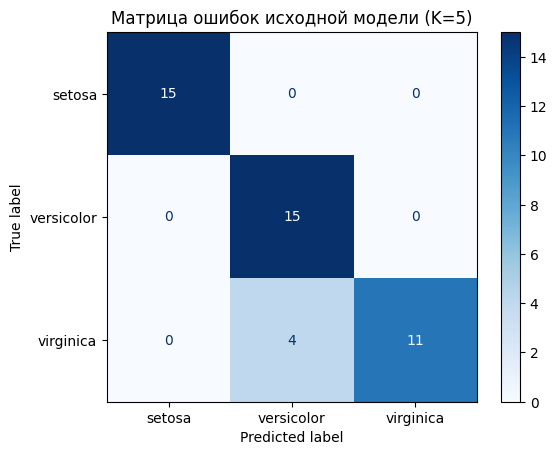

In [5]:
# Произвольно задаем K = 5
base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)

# Метрики исходной модели
base_accuracy = accuracy_score(y_test, y_pred_base)
base_precision = precision_score(y_test, y_pred_base, average="weighted")
base_recall = recall_score(y_test, y_pred_base, average="weighted")
base_f1 = f1_score(y_test, y_pred_base, average="weighted")

print("\nМетрики исходной модели (K=5):")
print("Accuracy:", round(base_accuracy, 4))
print("Precision:", round(base_precision, 4))
print("Recall:", round(base_recall, 4))
print("F1-score:", round(base_f1, 4))

print("\nМатрица ошибок для исходной модели:")
print(confusion_matrix(y_test, y_pred_base))

print("\nClassification report для исходной модели:")
print(classification_report(y_test, y_pred_base, target_names=target_names))

# Визуализация матрицы ошибок для исходной модели
cm_base = confusion_matrix(y_test, y_pred_base)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=target_names)
disp_base.plot(cmap="Blues")
plt.title("Матрица ошибок исходной модели (K=5)")
plt.show()

# 5. Подбор гиперпараметров

In [7]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

param_dist = {
    "knn__n_neighbors": randint(1, 16),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

# Две стратегии кросс-валидации
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5.1 GridSearchCV + KFold

In [8]:
grid_kfold = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv_kfold,
    scoring="f1_weighted"
)
grid_kfold.fit(X_train, y_train)

print("\nЛучшие параметры GridSearchCV + KFold:")
print(grid_kfold.best_params_)
print("Лучшее значение F1:", round(grid_kfold.best_score_, 4))


Лучшие параметры GridSearchCV + KFold:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
Лучшее значение F1: 0.9729


# 5.2 GridSearchCV + StratifiedKFold

In [9]:
grid_stratified = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv_stratified,
    scoring="f1_weighted"
)
grid_stratified.fit(X_train, y_train)

print("\nЛучшие параметры GridSearchCV + StratifiedKFold:")
print(grid_stratified.best_params_)
print("Лучшее значение F1:", round(grid_stratified.best_score_, 4))


Лучшие параметры GridSearchCV + StratifiedKFold:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Лучшее значение F1: 0.9714


# 5.3 RandomizedSearchCV + KFold

In [10]:
random_kfold = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=12,
    cv=cv_kfold,
    scoring="f1_weighted",
    random_state=42
)
random_kfold.fit(X_train, y_train)

print("\nЛучшие параметры RandomizedSearchCV + KFold:")
print(random_kfold.best_params_)
print("Лучшее значение F1:", round(random_kfold.best_score_, 4))


Лучшие параметры RandomizedSearchCV + KFold:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
Лучшее значение F1: 0.9726


# 5.4 RandomizedSearchCV + StratifiedKFold

In [11]:
random_stratified = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=12,
    cv=cv_stratified,
    scoring="f1_weighted",
    random_state=42
)
random_stratified.fit(X_train, y_train)

print("\nЛучшие параметры RandomizedSearchCV + StratifiedKFold:")
print(random_stratified.best_params_)
print("Лучшее значение F1:", round(random_stratified.best_score_, 4))


Лучшие параметры RandomizedSearchCV + StratifiedKFold:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
Лучшее значение F1: 0.9714


# 6. Выбор оптимальной модели


Метрики оптимальной модели:
Accuracy: 0.9333
Precision: 0.9444
Recall: 0.9333
F1-score: 0.9327

Матрица ошибок оптимальной модели:
[[15  0  0]
 [ 0 15  0]
 [ 0  3 12]]

Classification report для оптимальной модели:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



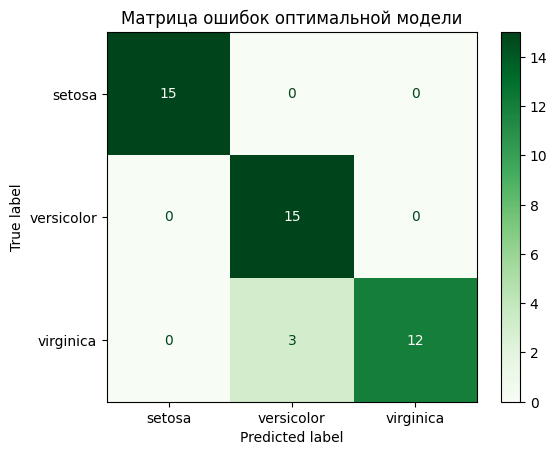

In [12]:
best_model = grid_stratified.best_estimator_
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

best_accuracy = accuracy_score(y_test, y_pred_best)
best_precision = precision_score(y_test, y_pred_best, average="weighted")
best_recall = recall_score(y_test, y_pred_best, average="weighted")
best_f1 = f1_score(y_test, y_pred_best, average="weighted")

print("\nМетрики оптимальной модели:")
print("Accuracy:", round(best_accuracy, 4))
print("Precision:", round(best_precision, 4))
print("Recall:", round(best_recall, 4))
print("F1-score:", round(best_f1, 4))

print("\nМатрица ошибок оптимальной модели:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification report для оптимальной модели:")
print(classification_report(y_test, y_pred_best, target_names=target_names))

# Визуализация матрицы ошибок оптимальной модели
cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=target_names)
disp_best.plot(cmap="Greens")
plt.title("Матрица ошибок оптимальной модели")
plt.show()

# 7. Сравнение исходной и оптимальной моделей


Сравнение моделей:
                  Модель  Accuracy  Precision    Recall  F1-score
0  Исходная модель (K=5)  0.911111   0.929825  0.911111  0.909502
1     Оптимальная модель  0.933333   0.944444  0.933333  0.932660


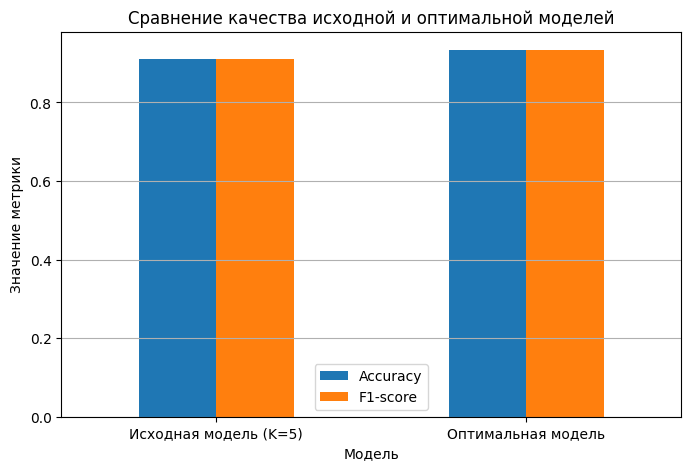

In [13]:
comparison_df = pd.DataFrame({
    "Модель": ["Исходная модель (K=5)", "Оптимальная модель"],
    "Accuracy": [base_accuracy, best_accuracy],
    "Precision": [base_precision, best_precision],
    "Recall": [base_recall, best_recall],
    "F1-score": [base_f1, best_f1]
})

print("\nСравнение моделей:")
print(comparison_df)

# График сравнения Accuracy и F1-score
comparison_df_plot = comparison_df.set_index("Модель")
comparison_df_plot[["Accuracy", "F1-score"]].plot(kind="bar", figsize=(8, 5))
plt.title("Сравнение качества исходной и оптимальной моделей")
plt.ylabel("Значение метрики")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()